In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

from dpks import QuantMatrix

In [2]:
design_matrix = pd.read_csv(
    "../tests/input_files/design_sepsis.tsv",
    sep="\t"
)

In [3]:
qm = QuantMatrix(
    quantification_file="../tests/input_files/data_sepsis.tsv",
    design_matrix_file=design_matrix,
).filter(
    remove_zero_rows=True,
    remove_n_zero_rows=True,
    max_n_zeros=int(design_matrix.shape[0] / 2),
).normalize(method="mean").quantify(method="top_n", top_n=3, summarization_method="mean")

/Users/aaron/Documents/projects/dpks/DPKS/dpks/quantification.py:94: RuntimeWarning: Mean of empty slice
  quantification: np.ndarray = np.nanmean(


In [4]:
fast_qm = qm.copy().compare(
    method="fast_ols",
    comparison=(2, 1)
)

linregress_qm = qm.copy().compare(
    method="linregress",
    comparison=(2, 1)
)

<Axes: xlabel='Log2FoldChange2-1', ylabel='-Log10CorrectedPValue2-1'>

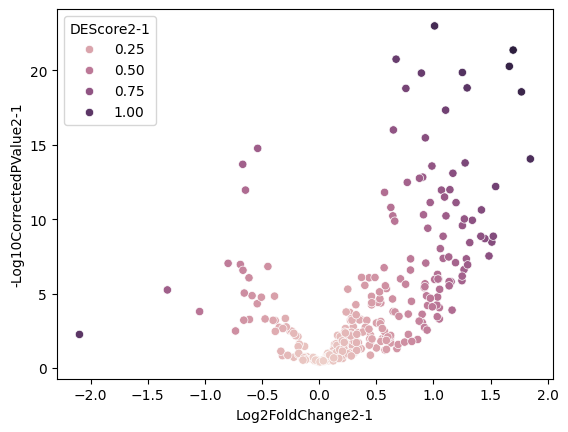

In [5]:
sns.scatterplot(
    data=fast_qm.row_annotations,
    x="Log2FoldChange2-1",
    y="-Log10CorrectedPValue2-1",
    hue="DEScore2-1",
)

<Axes: xlabel='Log2FoldChange2-1', ylabel='-Log10CorrectedPValue2-1'>

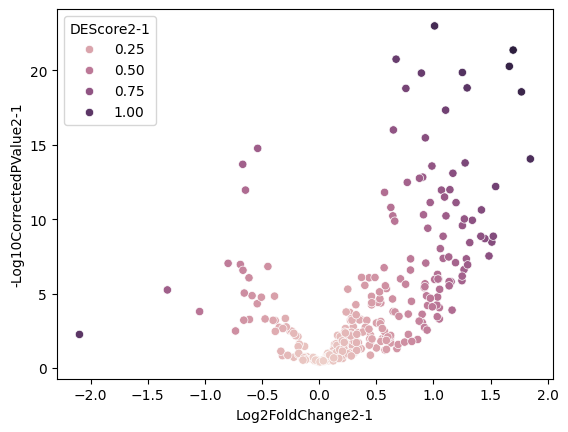

In [6]:
sns.scatterplot(
    data=linregress_qm.row_annotations,
    x="Log2FoldChange2-1",
    y="-Log10CorrectedPValue2-1",
    hue="DEScore2-1",
)

<Axes: xlabel='Log2FoldChange2-1', ylabel='Log2FoldChange2-1'>

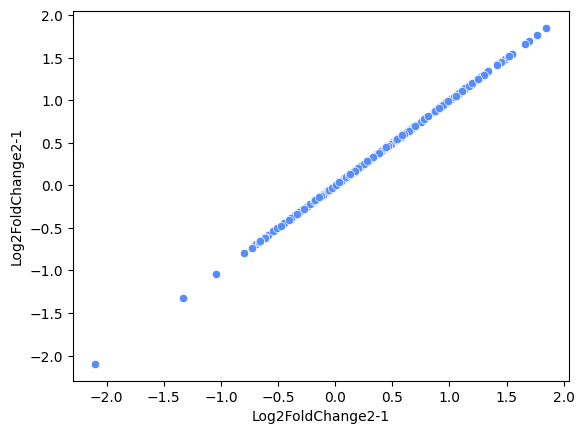

In [7]:
sns.scatterplot(
    x=linregress_qm.row_annotations['Log2FoldChange2-1'],
    y=fast_qm.row_annotations['Log2FoldChange2-1']
)